In [2]:
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

path_to_38_file = "/content/drive/My Drive/ptfiles/Wafer_Map_Datasets_1.npz"
data = np.load(path_to_38_file)

Mounted at /content/drive


#Augmentation

✅ Loaded dataset: X=(38015, 52, 52, 1), y=(38015, 8)

=== Per-Label Frequency (bit-wise) ===
Center    : 0.342
Donut     : 0.316
Edge_Loc  : 0.342
Edge_Ring : 0.316
Loc       : 0.473
Near_Full : 0.004
Scratch   : 0.500
Random    : 0.023

Per-label imbalance ratio (max/min): 127.52


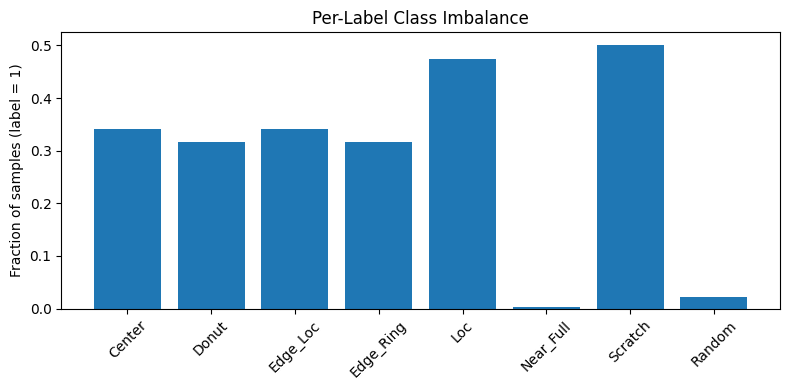


=== Combination Frequency (Top 10 of 38) ===
[1 0 1 0 0 0 1 0] -> 2000
[0 0 0 0 0 0 0 0] -> 1000
[0 0 0 0 1 0 1 0] -> 1000
[0 0 0 0 0 0 1 0] -> 1000
[0 0 0 1 0 0 0 0] -> 1000
[0 0 0 1 0 0 1 0] -> 1000
[0 0 0 1 1 0 1 0] -> 1000
[0 0 0 0 1 0 0 0] -> 1000
[0 0 1 0 1 0 0 0] -> 1000
[0 0 1 0 1 0 1 0] -> 1000

Combination imbalance ratio (max/min): 13.42


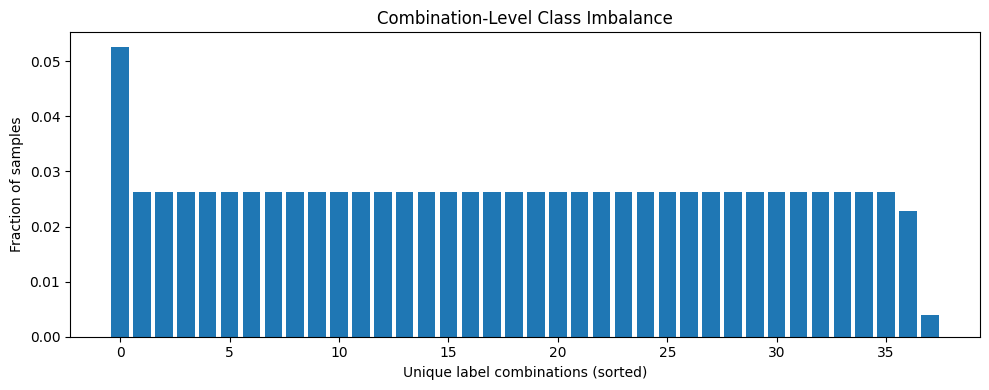


=== SUMMARY ===
Total unique label combinations : 38
Per-label imbalance ratio       : 127.52
Combination imbalance ratio     : 13.42

📄 Report saved to: experiment_results/imbalance_report.txt


In [3]:
# ================================================================
# CLASS IMBALANCE ANALYSIS (Per-Label + Combination)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os

# ================================================================
# 1️⃣ LOAD DATASET
# ================================================================

# --- Load ---
data = np.load(path_to_38_file)
X = data["arr_0"].astype("float32")     # normalized 0–1 inputs
y = data["arr_1"].astype("float32")     # binary multi-label targets (N × 8)

# Add channel dimension (for CNN models)
X = X[..., np.newaxis]                  # -> (N, 52, 52, 1)

print(f"✅ Loaded dataset: X={X.shape}, y={y.shape}")

# ================================================================
# 2️⃣ PER-LABEL CLASS IMBALANCE
# ================================================================

label_names = [
    "Center", "Donut", "Edge_Loc", "Edge_Ring",
    "Loc", "Near_Full", "Scratch", "Random"
]

# --- Compute frequency of '1' for each label ---
label_freq = y.mean(axis=0)

print("\n=== Per-Label Frequency (bit-wise) ===")
for name, freq in zip(label_names, label_freq):
    print(f"{name:<10}: {freq:.3f}")

# --- Quantitative imbalance ratio ---
imbalance_ratio_labels = label_freq.max() / label_freq.min()
print(f"\nPer-label imbalance ratio (max/min): {imbalance_ratio_labels:.2f}")

# --- Plot ---
plt.figure(figsize=(8, 4))
plt.bar(range(len(label_names)), label_freq)
plt.xticks(range(len(label_names)), label_names, rotation=45)
plt.ylabel("Fraction of samples (label = 1)")
plt.title("Per-Label Class Imbalance")
plt.tight_layout()
plt.show()

# ================================================================
# 3️⃣ COMBINATION-LEVEL IMBALANCE (Unique 8-bit Patterns)
# ================================================================

# --- Get unique label combinations and their counts efficiently ---
unique_labels, counts = np.unique(y, axis=0, return_counts=True)

# --- Sort by frequency (descending) ---
sorted_idx = np.argsort(-counts)
unique_labels = unique_labels[sorted_idx]
counts = counts[sorted_idx]

print(f"\n=== Combination Frequency (Top 10 of {len(unique_labels)}) ===")
for combo, count in zip(unique_labels[:10], counts[:10]):
    print(f"{combo.astype(int)} -> {count}")

# --- Normalized frequencies ---
comb_freqs = counts / counts.sum()

# --- Quantitative imbalance ratio ---
imbalance_ratio_combos = counts.max() / counts.min()
print(f"\nCombination imbalance ratio (max/min): {imbalance_ratio_combos:.2f}")

# --- Plot combination imbalance histogram ---
plt.figure(figsize=(10, 4))
plt.bar(range(len(comb_freqs)), comb_freqs)
plt.ylabel("Fraction of samples")
plt.xlabel("Unique label combinations (sorted)")
plt.title("Combination-Level Class Imbalance")
plt.tight_layout()
plt.show()

# ================================================================
# 4️⃣ SUMMARY REPORT
# ================================================================

print("\n=== SUMMARY ===")
print(f"Total unique label combinations : {len(unique_labels)}")
print(f"Per-label imbalance ratio       : {imbalance_ratio_labels:.2f}")
print(f"Combination imbalance ratio     : {imbalance_ratio_combos:.2f}")

# ================================================================
# (Optional) SAVE REPORT
# ================================================================
exp_dir = "experiment_results"
os.makedirs(exp_dir, exist_ok=True)

report_path = os.path.join(exp_dir, "imbalance_report.txt")
with open(report_path, "w") as f:
    f.write("=== CLASS IMBALANCE REPORT ===\n\n")
    f.write("Per-Label Frequencies:\n")
    for name, freq in zip(label_names, label_freq):
        f.write(f"{name:<10}: {freq:.3f}\n")
    f.write(f"\nPer-label imbalance ratio: {imbalance_ratio_labels:.2f}\n")
    f.write(f"\nTotal unique combinations: {len(unique_labels)}\n")
    f.write(f"Combination imbalance ratio: {imbalance_ratio_combos:.2f}\n\n")
    f.write("Top 10 Combinations:\n")
    for combo, count in zip(unique_labels[:10], counts[:10]):
        f.write(f"{combo.astype(int)} -> {count}\n")

print(f"\n📄 Report saved to: {report_path}")


In [4]:
# ================================================================
# TARGETED AUGMENTATION FOR RARE LABELS (Multi-Label Dataset)
# ================================================================

import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ================================================================
# 1️⃣ LOAD DATASET
# ================================================================
data = np.load(path_to_38_file)
X = data["arr_0"].astype("float32")    # (N, 52, 52)
y = data["arr_1"].astype("float32")    # (N, 8)
X = X[..., np.newaxis]                  # -> (N, 52, 52, 1)
print(f"✅ Loaded dataset: X={X.shape}, y={y.shape}")

label_names = [
    "Center", "Donut", "Edge_Loc", "Edge_Ring",
    "Loc", "Near_Full", "Scratch", "Random"
]

# ================================================================
# 2️⃣ ANALYZE LABEL FREQUENCIES
# ================================================================
label_freq = y.mean(axis=0)
target_freq = label_freq.mean()  # aim to balance near average
print("\n=== Per-Label Frequency (Before) ===")
for name, freq in zip(label_names, label_freq):
    print(f"{name:<10}: {freq:.3f}")

# Compute how many × each rare label should be increased
augment_multipliers = np.clip(np.round(target_freq / label_freq), 1, None).astype(int)
print("\nRecommended augmentation factors per label:")
for name, mul in zip(label_names, augment_multipliers):
    print(f"{name:<10}: {mul}×")

# ================================================================
# 3️⃣ DATA AUGMENTATION SETUP
# ================================================================
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

augmented_images = []
augmented_labels = []

# ================================================================
# 4️⃣ AUGMENT EACH RARE LABEL PROPORTIONALLY
# ================================================================
for idx, multiplier in enumerate(augment_multipliers):
    if multiplier <= 1:
        continue  # skip well-balanced labels

    # select all samples containing this label
    mask = y[:, idx] == 1
    X_sel = X[mask]
    y_sel = y[mask]

    print(f"\nAugmenting '{label_names[idx]}' ({len(X_sel)} samples) × {multiplier-1} extra...")

    for i in range(len(X_sel)):
        x = np.expand_dims(X_sel[i], axis=0)
        label = y_sel[i]
        j = 0
        for batch in datagen.flow(x, batch_size=1):
            augmented_images.append(batch[0])
            augmented_labels.append(label)
            j += 1
            if j >= (multiplier - 1):  # add only required extra copies
                break

aug_X = np.array(augmented_images)
aug_y = np.array(augmented_labels)
print(f"\n✅ Generated {aug_X.shape[0]} augmented samples.")

# ================================================================
# 5️⃣ COMBINE ORIGINAL + AUGMENTED DATA
# ================================================================
X_balanced = np.concatenate([X, aug_X], axis=0)
y_balanced = np.concatenate([y, aug_y], axis=0)
print(f"📊 Balanced dataset: X={X_balanced.shape}, y={y_balanced.shape}")

# ================================================================
# 6️⃣ SAVE AUGMENTED DATASET
# ================================================================
save_path = "balanced_dataset_auto.npz"
np.savez_compressed(save_path, X_balanced, y_balanced)
print(f"\n💾 Balanced dataset saved to: {save_path}")


✅ Loaded dataset: X=(38015, 52, 52, 1), y=(38015, 8)

=== Per-Label Frequency (Before) ===
Center    : 0.342
Donut     : 0.316
Edge_Loc  : 0.342
Edge_Ring : 0.316
Loc       : 0.473
Near_Full : 0.004
Scratch   : 0.500
Random    : 0.023

Recommended augmentation factors per label:
Center    : 1×
Donut     : 1×
Edge_Loc  : 1×
Edge_Ring : 1×
Loc       : 1×
Near_Full : 74×
Scratch   : 1×
Random    : 13×

Augmenting 'Near_Full' (149 samples) × 73 extra...

Augmenting 'Random' (866 samples) × 12 extra...

✅ Generated 21269 augmented samples.
📊 Balanced dataset: X=(59284, 52, 52, 1), y=(59284, 8)

💾 Balanced dataset saved to: balanced_dataset_auto.npz


✅ Loaded dataset: X=(59284, 52, 52, 1, 1), y=(59284, 8)

=== Per-Label Frequency (bit-wise) ===
Center    : 0.219
Donut     : 0.202
Edge_Loc  : 0.219
Edge_Ring : 0.202
Loc       : 0.304
Near_Full : 0.186
Scratch   : 0.320
Random    : 0.190

Per-label imbalance ratio (max/min): 1.72


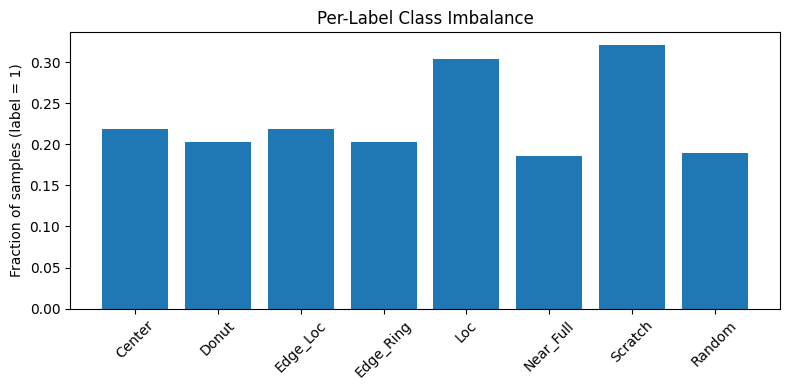


=== SUMMARY ===
Total unique label combinations : 38
Per-label imbalance ratio       : 1.72


In [5]:
# ================================================================
# CLASS IMBALANCE ANALYSIS (Per-Label + Combination)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os

# ================================================================
# 1️⃣ LOAD DATASET
# ================================================================

# --- Load ---
data = np.load("balanced_dataset_auto.npz")
X = data["arr_0"].astype("float32")     # normalized 0–1 inputs
y = data["arr_1"].astype("float32")     # binary multi-label targets (N × 8)

# Add channel dimension (for CNN models)
X = X[..., np.newaxis]                  # -> (N, 52, 52, 1)

print(f"✅ Loaded dataset: X={X.shape}, y={y.shape}")

# ================================================================
# 2️⃣ PER-LABEL CLASS IMBALANCE
# ================================================================

label_names = [
    "Center", "Donut", "Edge_Loc", "Edge_Ring",
    "Loc", "Near_Full", "Scratch", "Random"
]

# --- Compute frequency of '1' for each label ---
label_freq = y.mean(axis=0)

print("\n=== Per-Label Frequency (bit-wise) ===")
for name, freq in zip(label_names, label_freq):
    print(f"{name:<10}: {freq:.3f}")

# --- Quantitative imbalance ratio ---
imbalance_ratio_labels = label_freq.max() / label_freq.min()
print(f"\nPer-label imbalance ratio (max/min): {imbalance_ratio_labels:.2f}")

# --- Plot ---
plt.figure(figsize=(8, 4))
plt.bar(range(len(label_names)), label_freq)
plt.xticks(range(len(label_names)), label_names, rotation=45)
plt.ylabel("Fraction of samples (label = 1)")
plt.title("Per-Label Class Imbalance")
plt.tight_layout()
plt.show()


# ================================================================
# 4️⃣ SUMMARY REPORT
# ================================================================

print("\n=== SUMMARY ===")
print(f"Total unique label combinations : {len(unique_labels)}")
print(f"Per-label imbalance ratio       : {imbalance_ratio_labels:.2f}")

#Experiment

In [6]:
!pip install iterative-stratification
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 31.2 MB/s eta 0:00:00


In [7]:
# ================================================================
#   GhostNet Wafer Classifier — Version 5 (CAGCN)
#   Adds Class-Adaptive Calibration Head  (alpha, beta scales)
# ================================================================

import numpy as np
import tensorflow as tf
import optuna
import os, random, json
from datetime import datetime
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import f1_score, classification_report
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

# ================================================================
# 1. GLOBAL SETTINGS (Seeds + GPU + Mixed Precision)
# ================================================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
tf.keras.mixed_precision.set_global_policy("mixed_float16")
tf.config.experimental.enable_tensor_float_32_execution(True)

# ================================================================
# 2. LOAD DATA (WM-38k)
# ================================================================
# Replace with correct path to your dataset
# Example:  data = np.load("WM38k_dataset.npz")

X = data["arr_0"].astype("float32")    # normalized 0–1
y = data["arr_1"].astype("float32")
X = X[..., np.newaxis]                 # (N, 52, 52, 1)

# ================================================================
# 3. MULTILABEL STRATIFIED SPLIT (Train / Val / Cal / Test)
# ================================================================
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(msss.split(X, y))
X_train, y_train = X[train_idx], y[train_idx]
X_temp,  y_temp  = X[temp_idx],  y[temp_idx]

msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.66, random_state=SEED)
val_idx, temp2_idx = next(msss2.split(X_temp, y_temp))
X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_temp2, y_temp2 = X_temp[temp2_idx], y_temp[temp2_idx]

msss3 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
cal_idx, test_idx = next(msss3.split(X_temp2, y_temp2))
X_cal, y_cal = X_temp2[cal_idx], y_temp2[cal_idx]
X_test, y_test = X_temp2[test_idx], y_temp2[test_idx]

print("✅ Split shapes:",
      "\nTrain:", X_train.shape,
      "\nVal:",   X_val.shape,
      "\nCal:",   X_cal.shape,
      "\nTest:",  X_test.shape)

# ================================================================
# 4. CLASS IMBALANCE HANDLING — POS WEIGHT + LOSS
# ================================================================
pos = y_train.sum(axis=0)
neg = y_train.shape[0] - pos
pos_weight = (neg / (pos + 1e-6)).astype("float32")
print("✅ POS WEIGHT:", pos_weight)

def weighted_bce_loss(pos_weight):
    pos_weight = tf.constant(pos_weight, dtype=tf.float32)
    def loss(y_true, y_pred):
        eps = 1e-7
        y_pred = tf.clip_by_value(y_pred, eps, 1 - eps)
        logits = tf.math.log(y_pred / (1 - y_pred))
        loss_val = tf.nn.weighted_cross_entropy_with_logits(
            labels=y_true, logits=logits, pos_weight=pos_weight)
        return tf.reduce_mean(loss_val)
    return loss

# ================================================================
# 5. MODEL BLOCKS — SE Block + Ghost Module + Calibration Layer
# ================================================================
def se_block(x, reduction=4):
    f = int(x.shape[-1])
    r = max(1, f // reduction)
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(r, activation="relu")(se)
    se = layers.Dense(f, activation="sigmoid")(se)
    se = layers.Reshape((1,1,f))(se)
    return layers.Multiply()([x, se])

def ghost_module(x, out_channels, ratio=2):
    init_channels = int(out_channels / ratio)
    p = layers.Conv2D(init_channels, 1, padding="same", use_bias=False)(x)
    p = layers.BatchNormalization()(p)
    p = layers.ReLU()(p)
    c = layers.DepthwiseConv2D(3, padding="same", depth_multiplier=ratio-1, use_bias=False)(p)
    c = layers.BatchNormalization()(c)
    c = layers.ReLU()(c)
    return layers.Concatenate()([p, c])

# NEW: Class-Adaptive Calibration Layer
class ClassAdaptiveCalibration(tf.keras.layers.Layer):
    """Learns per-class scale (alpha) and bias (beta) to rescale logits."""
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

    def build(self, input_shape):
        self.alpha = self.add_weight(
            name='alpha', shape=(self.num_classes,),
            initializer='ones', trainable=True, dtype=tf.float32)
        self.beta = self.add_weight(
            name='beta', shape=(self.num_classes,),
            initializer='zeros', trainable=True, dtype=tf.float32)
        super().build(input_shape)

    def call(self, logits):
        scaled = self.alpha * logits + self.beta
        return tf.nn.sigmoid(scaled)


Num GPUs Available: 1
✅ Split shapes: 
Train: (41498, 52, 52, 1, 1) 
Val: (6047, 52, 52, 1, 1) 
Cal: (5869, 52, 52, 1, 1) 
Test: (5870, 52, 52, 1, 1)
✅ POS WEIGHT: [3.5602198 3.940238  3.5602198 3.940238  2.293492  4.3767815 2.1201503
 4.2662435]


In [8]:
# ================================================================
# 6. BUILD MODEL (CAGCN version)
# ================================================================
def build_model(trial, input_shape=(52,52,1), num_classes=8):
    # --- Hyperparameter search space ---
    ch1 = trial.suggest_categorical("ch1", [16, 32, 48])
    ch2 = trial.suggest_categorical("ch2", [32, 64, 96])
    ch3 = trial.suggest_categorical("ch3", [64, 128, 192])
    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    # --- Architecture ---
    inp = layers.Input(shape=input_shape)
    x = ghost_module(inp, ch1); x = se_block(x); x = layers.MaxPooling2D()(x)
    x = ghost_module(x, ch2);   x = se_block(x); x = layers.MaxPooling2D()(x)
    x = ghost_module(x, ch3);   x = se_block(x); x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)

    # logits (no sigmoid)
    logits = layers.Dense(num_classes, dtype="float32")(x)

    # --- Apply Class-Adaptive Calibration ---
    calibrated = ClassAdaptiveCalibration(num_classes)(logits)

    model = models.Model(inp, calibrated)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=weighted_bce_loss(pos_weight),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="bin_acc"),
            tf.keras.metrics.Precision(name="prec"),
            tf.keras.metrics.Recall(name="rec"),
            tf.keras.metrics.AUC(name="auc", multi_label=True),
        ],
    )
    return model

# ================================================================
# 7. OPTUNA OBJECTIVE FUNCTION
# ================================================================
def objective(trial):
    model = build_model(trial)
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5),
    ]

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=25,
        batch_size=64,
        callbacks=callbacks,
        verbose=0,
    )

    # --- Compute validation F1 (macro) ---
    y_val_pred = (model.predict(X_val) > 0.5).astype(int)
    val_f1 = f1_score(y_val, y_val_pred, average="macro", zero_division=0)
    print(f"Trial {trial.number} → val_F1: {val_f1:.4f}")
    return val_f1

# ================================================================
# 8. RUN OPTUNA STUDY
# ================================================================
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=10)
print("✅ Best trial params:", study.best_trial.params)

# ================================================================
# 9. TRAIN FINAL MODEL USING BEST PARAMS
# ================================================================
best_trial = study.best_trial
model = build_model(best_trial)

exp_dir = f"experiment_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(exp_dir, exist_ok=True)

checkpoint = ModelCheckpoint(
    os.path.join(exp_dir, "best_model.h5"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

callbacks = [
    checkpoint,
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=2, factor=0.5),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)
print("✅ Base model training complete.")

[I 2025-11-15 05:25:13,795] A new study created in memory with name: no-name-e17acdff-c8e5-4199-a4c2-e51eed48caed


189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step


[I 2025-11-15 05:28:47,969] Trial 0 finished with value: 0.9653522522855342 and parameters: {'ch1': 32, 'ch2': 32, 'ch3': 128, 'dense_units': 256, 'dropout': 0.4329770563201687, 'lr': 0.00022948683681130568}. Best is trial 0 with value: 0.9653522522855342.


Trial 0 → val_F1: 0.9654
189/189 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step


[I 2025-11-15 05:32:08,503] Trial 1 finished with value: 0.9837877730011239 and parameters: {'ch1': 48, 'ch2': 32, 'ch3': 64, 'dense_units': 256, 'dropout': 0.1798695128633439, 'lr': 0.000747599299995651}. Best is trial 1 with value: 0.9837877730011239.


...

649/649 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - auc: 0.9990 - bin_acc: 0.9924 - loss: 0.0345 - prec: 0.9783 - rec: 0.9891 - val_auc: 0.9989 - val_bin_acc: 0.9919 - val_loss: 0.0378 - val_prec: 0.9783 - val_rec: 0.9868 - learning_rate: 5.5968e-04
Epoch 14/30
649/649 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9989 - bin_acc: 0.9927 - loss: 0.0346 - prec: 0.9790 - rec: 0.9895
Epoch 14: val_loss improved from 0.03777 to 0.03639, saving model to experiment_20251115_055425/best_model.h5


649/649 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - auc: 0.9989 - bin_acc: 0.9927 - loss: 0.0346 - prec: 0.9790 - rec: 0.9895 - val_auc: 0.9989 - val_bin_acc: 0.9927 - val_loss: 0.0364 - val_prec: 0.9806 - val_rec: 0.9877 - learning_rate: 5.5968e-04
Epoch 15/30
646/649 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.9990 - bin_acc: 0.9929 - loss: 0.0326 - prec: 0.9793 - rec: 0.9900
Epoch 15: val_loss improved from 0.03639 to 0.03573, saving model to experiment_20251115_055425/best_model.h5


649/649 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - auc: 0.9990 - bin_acc: 0.9929 - loss: 0.0326 - prec: 0.9793 - rec: 0.9900 - val_auc: 0.9989 - val_bin_acc: 0.9930 - val_loss: 0.0357 - val_prec: 0.9824 - val_rec: 0.9873 - learning_rate: 5.5968e-04
Epoch 16/30
647/649 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.9991 - bin_acc: 0.9931 - loss: 0.0314 - prec: 0.9800 - rec: 0.9901
Epoch 16: val_loss did not improve from 0.03573
649/649 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - auc: 0.9991 - bin_acc: 0.9931 - loss: 0.0314 - prec: 0.9800 - rec: 0.9901 - val_auc: 0.9989 - val_bin_acc: 0.9931 - val_loss: 0.0363 - val_prec: 0.9837 - val_rec: 0.9865 - learning_rate: 5.5968e-04
Epoch 17/30
648/649 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.9991 - bin_acc: 0.9933 - loss: 0.0310 - prec: 0.9807 - rec: 0.9904
Epoch 17: val_loss improved from 0.03573 to 0.03544, saving model to experiment_20251115_055425/best_model.h5


649/649 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - auc: 0.9991 - bin_acc: 0.9933 - loss: 0.0310 - prec: 0.9807 - rec: 0.9904 - val_auc: 0.9989 - val_bin_acc: 0.9929 - val_loss: 0.0354 - val_prec: 0.9809 - val_rec: 0.9884 - learning_rate: 5.5968e-04
Epoch 18/30
643/649 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - auc: 0.9992 - bin_acc: 0.9933 - loss: 0.0304 - prec: 0.9804 - rec: 0.9908
Epoch 18: val_loss improved from 0.03544 to 0.03542, saving model to experiment_20251115_055425/best_model.h5


649/649 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - auc: 0.9992 - bin_acc: 0.9933 - loss: 0.0304 - prec: 0.9804 - rec: 0.9908 - val_auc: 0.9988 - val_bin_acc: 0.9931 - val_loss: 0.0354 - val_prec: 0.9825 - val_rec: 0.9878 - learning_rate: 5.5968e-04
Epoch 19/30
648/649 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9992 - bin_acc: 0.9934 - loss: 0.0297 - prec: 0.9808 - rec: 0.9909
Epoch 19: val_loss did not improve from 0.03542
649/649 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - auc: 0.9992 - bin_acc: 0.9934 - loss: 0.0298 - prec: 0.9808 - rec: 0.9909 - val_auc: 0.9987 - val_bin_acc: 0.9927 - val_loss: 0.0374 - val_prec: 0.9813 - val_rec: 0.9870 - learning_rate: 5.5968e-04
Epoch 20/30
645/649 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.9992 - bin_acc: 0.9939 - loss: 0.0281 - prec: 0.9823 - rec: 0.9914
Epoch 20: val_loss did not improve from 0.03542
649/649 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - auc: 0.9992 - bin_acc: 0.9939 - loss: 0.0281 - prec: 0.9823 - rec: 0.9914 - val_auc: 0.9988 - val_bin_acc: 0.9933 - val_

In [9]:
# ================================================================
# 10. CALIBRATION FINE-TUNING (Train α, β only)
# ================================================================
print("\n=== Fine-tuning Class-Adaptive Calibration Head ===")

# Freeze all layers except the ClassAdaptiveCalibration layer
for layer in model.layers:
    if not isinstance(layer, ClassAdaptiveCalibration):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=weighted_bce_loss(pos_weight),
    metrics=[tf.keras.metrics.AUC(name="auc", multi_label=True)],
)

model.fit(
    X_cal, y_cal,
    epochs=5,
    batch_size=64,
    verbose=1,
    validation_data=(X_val, y_val),
)
print("✅ Calibration fine-tuning complete.")

# Save calibration parameters
cal_layer = [l for l in model.layers if isinstance(l, ClassAdaptiveCalibration)][0]
alpha_vals = cal_layer.alpha.numpy()
beta_vals  = cal_layer.beta.numpy()
np.save(os.path.join(exp_dir, "alpha.npy"), alpha_vals)
np.save(os.path.join(exp_dir, "beta.npy"), beta_vals)
print("✅ Saved calibration parameters.")

# ================================================================
# 11. THRESHOLD CALIBRATION (on calibration set)
# ================================================================
y_cal_prob = model.predict(X_cal)
best_thresholds = []
for i in range(y_cal.shape[1]):
    best_t, best_f1 = 0.5, 0
    for t in np.linspace(0.1, 0.9, 81):
        preds = (y_cal_prob[:, i] > t).astype(int)
        f1 = f1_score(y_cal[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresholds.append(best_t)
np.save(os.path.join(exp_dir, "thresholds.npy"), np.array(best_thresholds))
print("✅ Calibrated thresholds:", best_thresholds)




=== Fine-tuning Class-Adaptive Calibration Head ===
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 177ms/step - auc: 0.9985 - loss: 0.0400 - val_auc: 0.9988 - val_loss: 0.0354
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9983 - loss: 0.0422 - val_auc: 0.9988 - val_loss: 0.0353
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9984 - loss: 0.0409 - val_auc: 0.9988 - val_loss: 0.0352
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9985 - loss: 0.0391 - val_auc: 0.9988 - val_loss: 0.0352
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9984 - loss: 0.0404 - val_auc: 0.9988 - val_loss: 0.0351
✅ Calibration fine-tuning complete.
✅ Saved calibration parameters.
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step
✅ Calibrated thresholds: [np.float64(0.67), np.float64(0.1), np.float64(0.66), np.float64(0.73), np.float64(0.71), np.float64(0.66), np.float64(0.79), np.float64(0.85)]


In [10]:
# ================================================================
# 12. FINAL TEST EVALUATION (Complete + Save Report)
# ================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    hamming_loss,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ---------------------------------------------------------------
# 1️⃣ Model prediction and thresholding
# ---------------------------------------------------------------
y_test_prob = model.predict(X_test)
y_pred = (y_test_prob > best_thresholds).astype(int)

# ---------------------------------------------------------------
# 2️⃣ Add "None" label (when no class is active)
# ---------------------------------------------------------------
none_pred = (y_pred.sum(axis=1) == 0).astype(int)
none_true = (y_test.sum(axis=1) == 0).astype(int)

y_pred_full = np.column_stack([y_pred, none_pred])
y_true_full = np.column_stack([y_test, none_true])

label_names = [
    "Center", "Donut", "Edge_Loc", "Edge_Ring",
    "Loc", "Near_Full", "Scratch", "Random", "None"
]

# ---------------------------------------------------------------
# 3️⃣ Detailed per-label classification report
# ---------------------------------------------------------------
report = classification_report(
    y_true_full, y_pred_full,
    target_names=label_names,
    zero_division=0
)

# ---------------------------------------------------------------
# 4️⃣ Global multi-label metrics
# ---------------------------------------------------------------
subset_acc = accuracy_score(y_true_full, y_pred_full)
hamming = hamming_loss(y_true_full, y_pred_full)
micro_f1 = f1_score(y_true_full, y_pred_full, average="micro")
macro_f1 = f1_score(y_true_full, y_pred_full, average="macro")

global_metrics = (
    f"\n=== GLOBAL METRICS ===\n"
    f"Subset accuracy (exact match): {subset_acc:.4f}\n"
    f"Hamming loss (fraction of wrong bits): {hamming:.4f}\n"
    f"Micro F1 (bitwise): {micro_f1:.4f}\n"
    f"Macro F1 (bitwise): {macro_f1:.4f}\n"
)

# ---------------------------------------------------------------
# 5️⃣ Combine report + metrics into a single text
# ---------------------------------------------------------------
full_report = (
    "=== FINAL TEST REPORT ===\n"
    + report
    + global_metrics
)

print(full_report)

# ---------------------------------------------------------------
# 6️⃣ Save report to file
# ---------------------------------------------------------------
os.makedirs(exp_dir, exist_ok=True)
report_path = os.path.join(exp_dir, "test_report.txt")

with open(report_path, "w") as f:
    f.write(full_report)

confmat_dir = os.path.join(exp_dir, "confusion_matrices")
os.makedirs(confmat_dir, exist_ok=True)

for i, name in enumerate(label_names):
    cm = confusion_matrix(y_true_full[:, i], y_pred_full[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix – {name}")

    # ✅ Save each confusion matrix image in its own file
    cm_path = os.path.join(confmat_dir, f"confmat_{name}.png")
    plt.savefig(cm_path, bbox_inches="tight")
    plt.close()

with open(os.path.join(exp_dir, "best_params.json"), "w") as f:
    json.dump(study.best_trial.params, f, indent=2)

print("✅ (CAGCN)")
print(f"\n✅ Experiment saved in: {exp_dir}")

184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step
=== FINAL TEST REPORT ===
              precision    recall  f1-score   support

      Center       1.00      1.00      1.00      1287
       Donut       1.00      1.00      1.00      1188
    Edge_Loc       0.98      0.98      0.98      1287
   Edge_Ring       0.98      0.99      0.99      1188
         Loc       0.99      0.96      0.97      1782
   Near_Full       0.99      0.99      0.99      1092
     Scratch       0.98      0.96      0.97      1881
      Random       0.99      0.99      0.99      1115
        None       0.98      1.00      0.99       121

   micro avg       0.99      0.98      0.99     10941
   macro avg       0.99      0.99      0.99     10941
weighted avg       0.99      0.98      0.99     10941
 samples avg       0.99      0.99      0.99     10941

=== GLOBAL METRICS ===
Subset accuracy (exact match): 0.9537
Hamming loss (fraction of wrong bits): 0.0061
Micro F1 (bitwise): 0.9852
Macro F1 (bitwise): 0.9870

✅ (CAGCN)

